# 02_allocation
margin_matrix と segment_demand を用いて貪欲配賦アルゴリズムを実行し、構成比と粗利インパクトを確認する。

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_ROOT = Path.cwd()
PROJECT_ROOT = NOTEBOOK_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'scripts'))

from allocation_utils import CapacityConfig, build_option_table, greedy_allocate, summarize_allocation

CAPACITY = {'A': 528000, 'B': 528000}
config = CapacityConfig(plant_capacity=CAPACITY, capacity_utilization_target=0.9, demand_scale=1.0)


In [2]:
data_dir = PROJECT_ROOT / 'data' / 'intermediate'
margin_matrix = pd.read_parquet(data_dir / 'margin_matrix.parquet')
segment_demand = pd.read_parquet(data_dir / 'segment_demand.parquet')
options = build_option_table(margin_matrix)
options.head()


,product_code,plant,segment,alloc_cap,unit_margin,margin_rate,avg_price,priority_score
0,P001,A,automotive,1192.000000,744.945872,0.496623,1496.269957,369.957144
1,P001,A,construction,946.000000,721.895492,0.490012,1473.219577,353.737562
2,P001,B,automotive,887.000000,675.853615,0.446277,1514.425727,301.618033
3,P001,B,construction,958.000000,551.973179,0.392961,1390.545291,216.903692
4,P002,A,chemical,1464.666667,666.623890,0.459791,1446.573344,306.507904


In [3]:
allocation_df, plant_remaining, demand_remaining = greedy_allocate(options, segment_demand, config)
allocation_df.head()


,product_code,plant,segment,alloc_qty,unit_margin,margin_rate,alloc_margin
0,P017,A,chemical,275.666667,3044.764340,0.457262,8.393400e+05
1,P020,A,automotive,467.000000,3119.416858,0.441824,1.456768e+06
2,P018,A,electronics,445.333333,3019.801428,0.437210,1.344818e+06
3,P013,A,chemical,199.333333,2917.091955,0.441177,5.814737e+05
4,P015,A,automotive,271.000000,2988.075583,0.414181,8.097685e+05


In [4]:
summaries = summarize_allocation(allocation_df, config, segment_demand, plant_remaining, demand_remaining)
plant_summary = summaries['plant']
segment_summary = summaries['segment']
display(plant_summary)
display(segment_summary)


,plant,allocated_qty,allocated_margin,capacity_limit,remaining_capacity,usage_rate
0,A,4909.172222,8.757066e+06,475200.0,470290.827778,0.010
1,B,1822.888889,1.754061e+06,475200.0,473377.111111,0.004


,segment,allocated_qty,allocated_margin,share,baseline_qty,delta_qty,remaining_demand
0,automotive,1154.000000,2.604007e+06,0.171,1154.000000,0.000000e+00,0.0
1,chemical,1015.200000,1.836033e+06,0.151,1015.200000,-1.136868e-13,0.0
2,construction,912.555556,1.069572e+06,0.136,912.555556,0.000000e+00,0.0
3,consumer,1386.666667,6.835230e+05,0.206,1386.666667,0.000000e+00,0.0
4,electronics,762.666667,2.022760e+06,0.113,762.666667,0.000000e+00,0.0
5,food_beverage,191.000000,4.263374e+05,0.028,191.000000,0.000000e+00,0.0
6,medical,245.222222,6.442007e+05,0.036,245.222222,0.000000e+00,0.0
7,others,1064.750000,1.224693e+06,0.158,1064.750000,0.000000e+00,0.0


C:\Users\atsuk\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27083 (\N{CJK UNIFIED IDEOGRAPH-69CB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\atsuk\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\atsuk\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\atsuk\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\atsuk\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 369

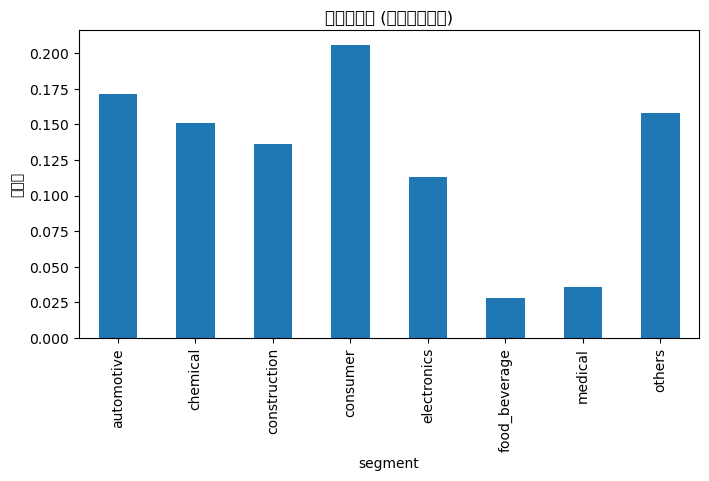

In [5]:
if not segment_summary.empty:
    plt.figure(figsize=(8, 4))
    segment_summary.set_index('segment')['share'].plot(kind='bar')
    plt.title('Optimized Segment Mix (by Segment)')
    plt.ylabel('Share')
    plt.xlabel('Segment')
    plt.show()


In [6]:
output_dir = PROJECT_ROOT / 'data' / 'intermediate'
allocation_df.to_parquet(output_dir / 'allocation_results.parquet', index=False)
plant_summary.to_parquet(output_dir / 'allocation_plant_summary.parquet', index=False)
segment_summary.to_parquet(output_dir / 'allocation_segment_summary.parquet', index=False)
print('allocation結果を書き出しました。')


allocation結果を書き出しました。
